# Import Relevant Libraries

In [1]:
# Import pandas library for data manipulation and analysis
import pandas as pd
# Import numpy for numerical operations
import numpy as np
# Import matplotlib.pyplot for creating visualizations
import matplotlib.pyplot as plt
# Import seaborn for statistical data visualization
import seaborn as sns

# Load the Dataset

In [2]:
df = pd.read_csv("retailmart_data.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1000 non-null   object 
 1   Category        1000 non-null   object 
 2   Region          1000 non-null   object 
 3   Weather         1000 non-null   object 
 4   Advertising     1000 non-null   float64
 5   Discount        1000 non-null   float64
 6   Month           1000 non-null   object 
 7   Year            1000 non-null   int64  
 8   Season          1000 non-null   object 
 9   Sales           1000 non-null   float64
 10  Customer_Count  1000 non-null   int64  
 11  Profit          1000 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 93.9+ KB


In [3]:
df.head()

,Date,Category,Region,Weather,Advertising,Discount,Month,Year,Season,Sales,Customer_Count,Profit
0,2022-01-01,Home Goods,East,Cloudy,1275.18,15.74,January,2022,Winter,2679.56,95,652.90
1,2022-01-02,Electronics,West,Cloudy,1893.89,24.74,January,2022,Winter,3859.05,147,924.16
2,2022-01-02,Apparel,East,Sunny,727.38,8.46,January,2022,Winter,2450.71,79,512.75
3,2022-01-02,Apparel,South,Rainy,1757.23,15.37,January,2022,Winter,3056.75,97,624.60
4,2022-01-05,Home Goods,North,Cloudy,1507.46,16.22,January,2022,Winter,2840.15,116,617.43


Time-Series Analysis

In [5]:
# Convert the Data column to pandas datetime format
df["Date"] = pd.to_datetime(df["Date"])

### Sales Trend over time for different Categories

In [6]:
df["Category"].unique()

array(['Home Goods', 'Electronics', 'Apparel'], dtype=object)

In [7]:
home_goods = df[df["Category"]=="Home Goods"]
electronics = df[df["Category"]=="Electronics"]
apparel = df[df["Category"]=="Apparel"]

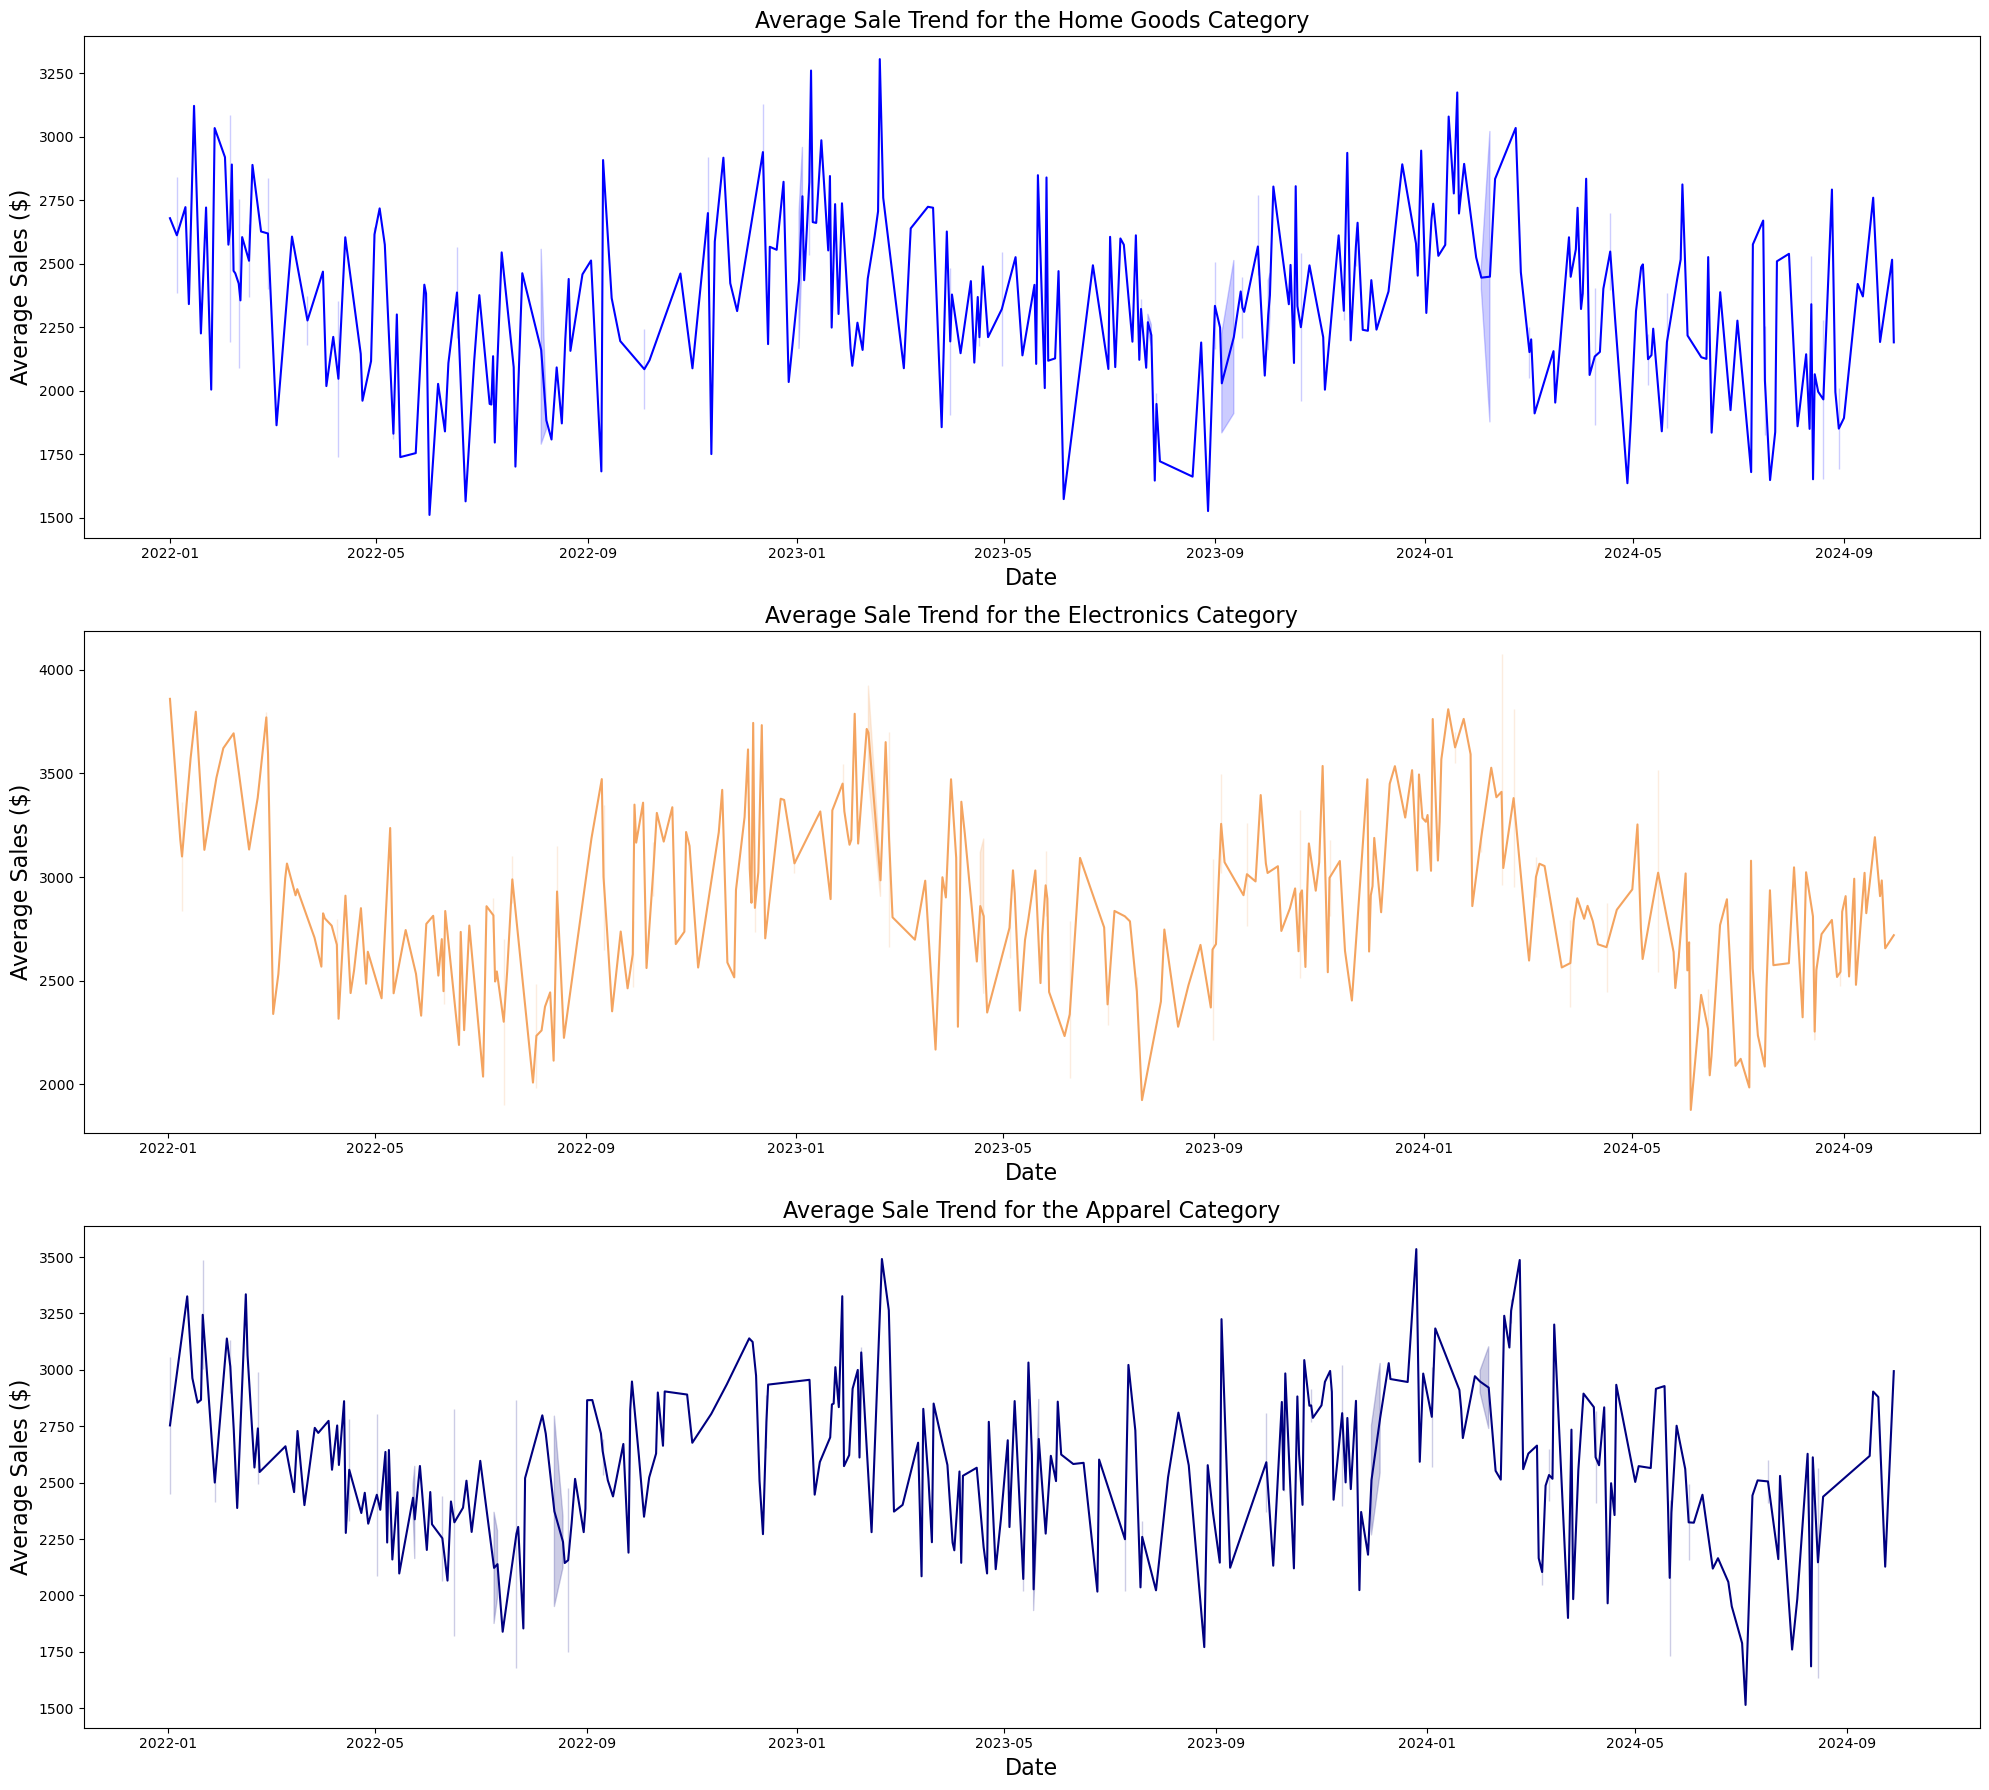

In [8]:
fig, ax = plt.subplots(nrows = 3, ncols = 1, figsize = (20,18))
sns.lineplot(x = "Date", y = "Sales", data = home_goods, ax = ax[0], color = "blue")
ax[0].set_title("Average Sale Trend for the Home Goods Category", fontsize = 16)
ax[0].set_xlabel("Date", fontsize = 16)
ax[0].set_ylabel("Average Sales ($)", fontsize = 16)


sns.lineplot(x = "Date", y = "Sales", data = electronics, ax = ax[1], color = "sandybrown")
ax[1].set_title("Average Sale Trend for the Electronics Category", fontsize = 16)
ax[1].set_xlabel("Date", fontsize = 16)
ax[1].set_ylabel("Average Sales ($)", fontsize = 16)

sns.lineplot(x = "Date", y = "Sales", data = apparel, ax = ax[2], color = "navy")
ax[2].set_title("Average Sale Trend for the Apparel Category", fontsize = 16)
ax[2].set_xlabel("Date", fontsize = 16)
ax[2].set_ylabel("Average Sales ($)", fontsize = 16)

plt.tight_layout()
plt.show()

### Let's visualise this seasonality across monthly sales

In [9]:
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)
df.head()

,Date,Category,Region,Weather,Advertising,Discount,Month,Year,Season,Sales,Customer_Count,Profit,Year_Month
0,2022-01-01,Home Goods,East,Cloudy,1275.18,15.74,January,2022,Winter,2679.56,95,652.90,2022-01
1,2022-01-02,Electronics,West,Cloudy,1893.89,24.74,January,2022,Winter,3859.05,147,924.16,2022-01
2,2022-01-02,Apparel,East,Sunny,727.38,8.46,January,2022,Winter,2450.71,79,512.75,2022-01
3,2022-01-02,Apparel,South,Rainy,1757.23,15.37,January,2022,Winter,3056.75,97,624.60,2022-01
4,2022-01-05,Home Goods,North,Cloudy,1507.46,16.22,January,2022,Winter,2840.15,116,617.43,2022-01


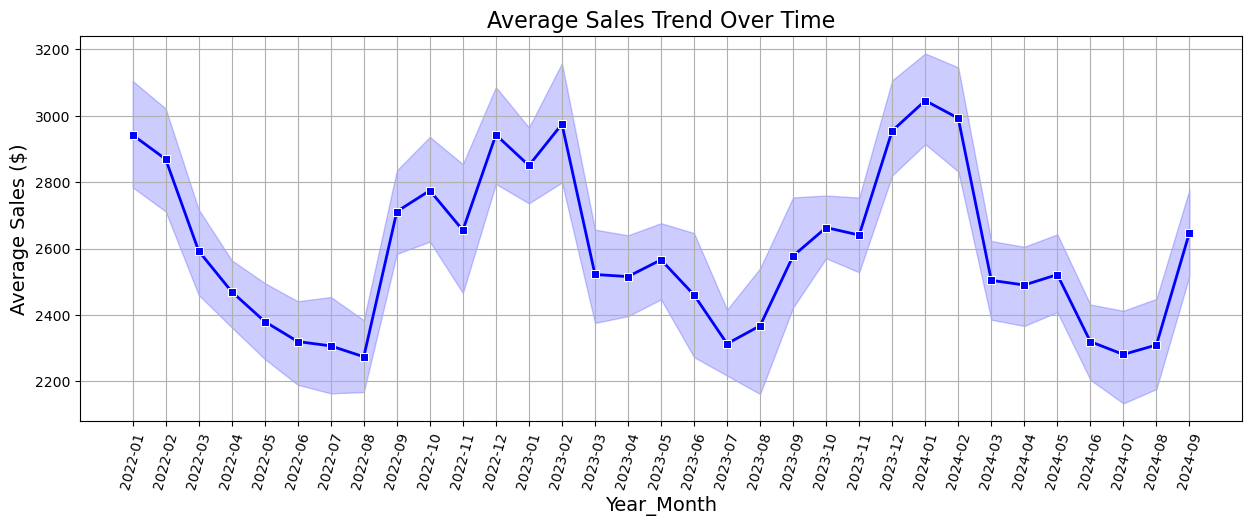

In [10]:
plt.figure(figsize = (15,5))

sns.lineplot(x = "Year_Month", y = "Sales", data = df, marker = "s", linewidth = 2, color = "blue")
plt.title("Average Sales Trend Over Time", fontsize = 16)
plt.xlabel("Year_Month", fontsize = 14)
plt.ylabel("Average Sales ($)", fontsize = 14)
plt.xticks(rotation = 75)
plt.grid(True)
plt.show()

### Trend by Ploting the Average Monthly Sales across different seasons

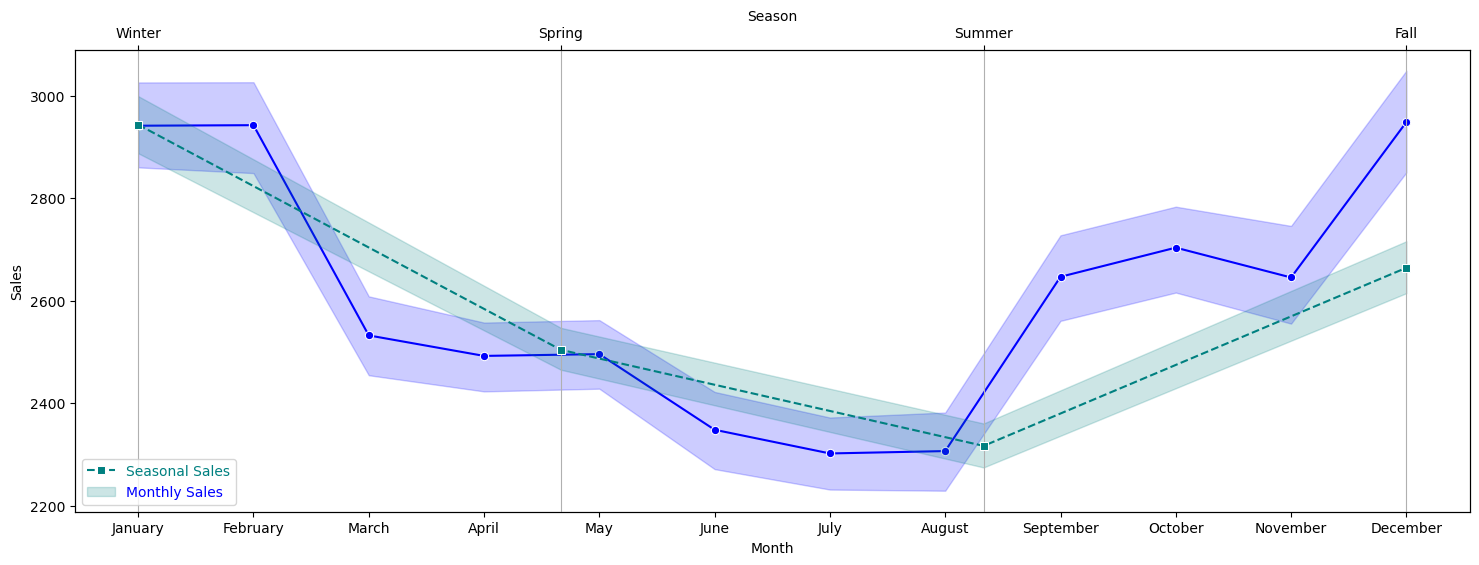

In [11]:
fig, ax = plt.subplots(figsize = (18,6))
sns.lineplot(x = "Month", y = "Sales", data = df, color = "blue", marker = "o")
ax2 = ax.twiny()

sns.lineplot(x = "Season", y = "Sales", data = df, color = "teal", marker = "s", linestyle = "--")

plt.legend(labels = ["Seasonal Sales", "Monthly Sales"], loc = "lower left", labelcolor = ["teal","blue"])
plt.grid(True)
plt.show()

### Customer Activity Analysis

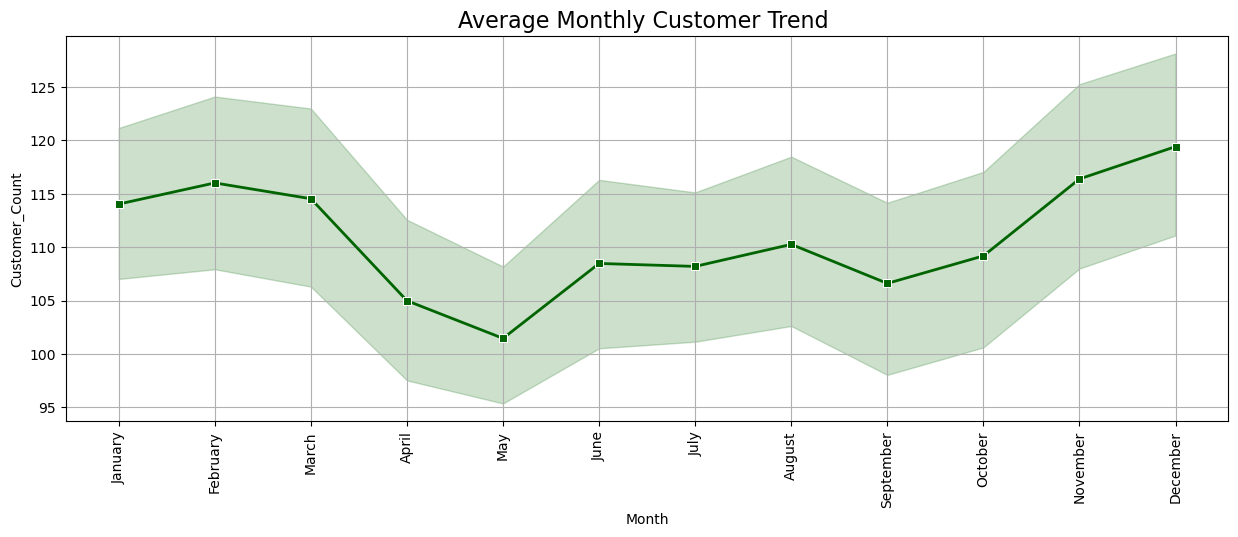

In [12]:
plt.figure(figsize = (15,5))
sns.lineplot(x = "Month", y = "Customer_Count", data = df, marker = "s", linewidth = 2, color = "darkgreen")
plt.title("Average Monthly Customer Trend ", fontsize = 16)
plt.xticks(rotation = 90)
plt.grid(True)
plt.show()

### Analysis Over the Entire Timeline

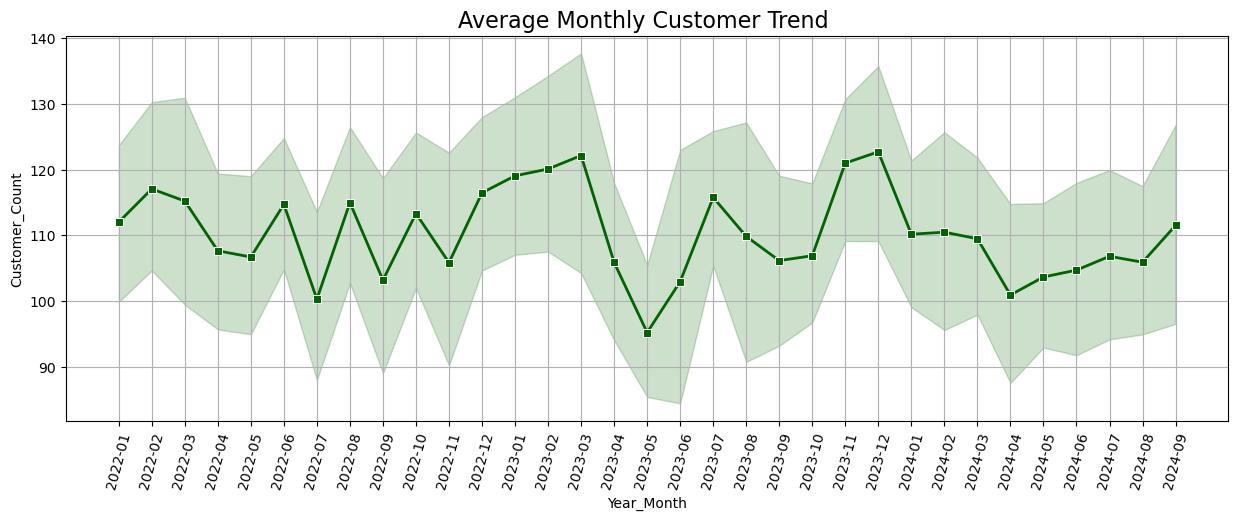

In [13]:
plt.figure(figsize = (15,5))
sns.lineplot(x = "Year_Month", y = "Customer_Count", data = df, marker = "s", linewidth = 2, color = "darkgreen")
plt.title("Average Monthly Customer Trend ", fontsize = 16)
plt.xticks(rotation = 75)
plt.grid(True)
plt.show()

### Advertising Analysis

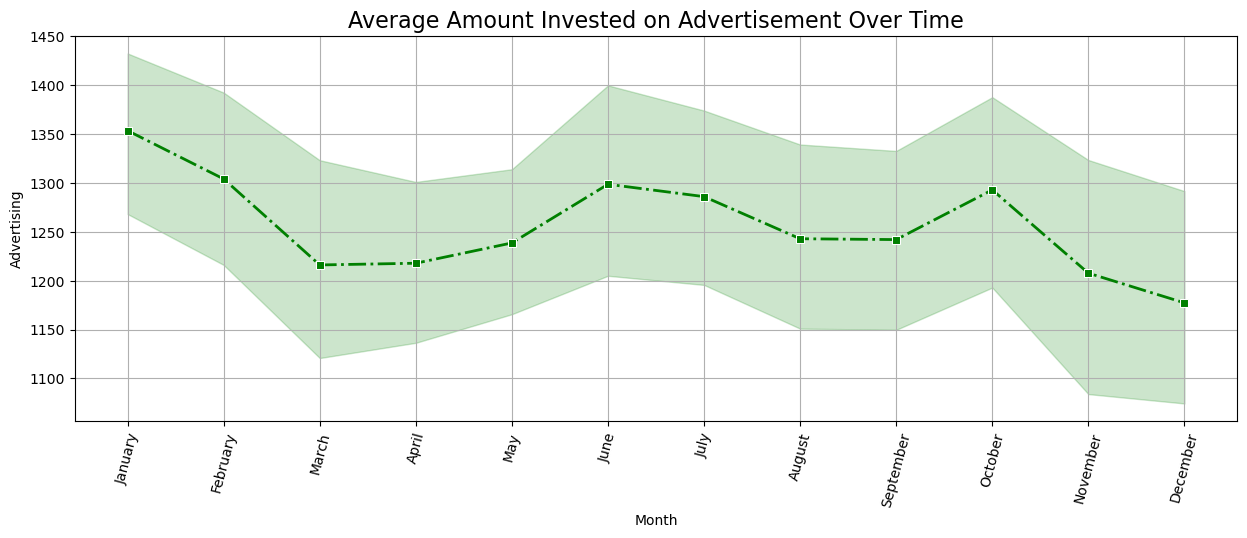

In [14]:
plt.figure(figsize = (15,5))
sns.lineplot(x = "Month", y = "Advertising", data = df, marker = "s", linewidth = 2, color = "green", linestyle = "-.")
plt.title("Average Amount Invested on Advertisement Over Time", fontsize = 16)
plt.xticks(rotation = 75)
plt.grid(True)
plt.show()

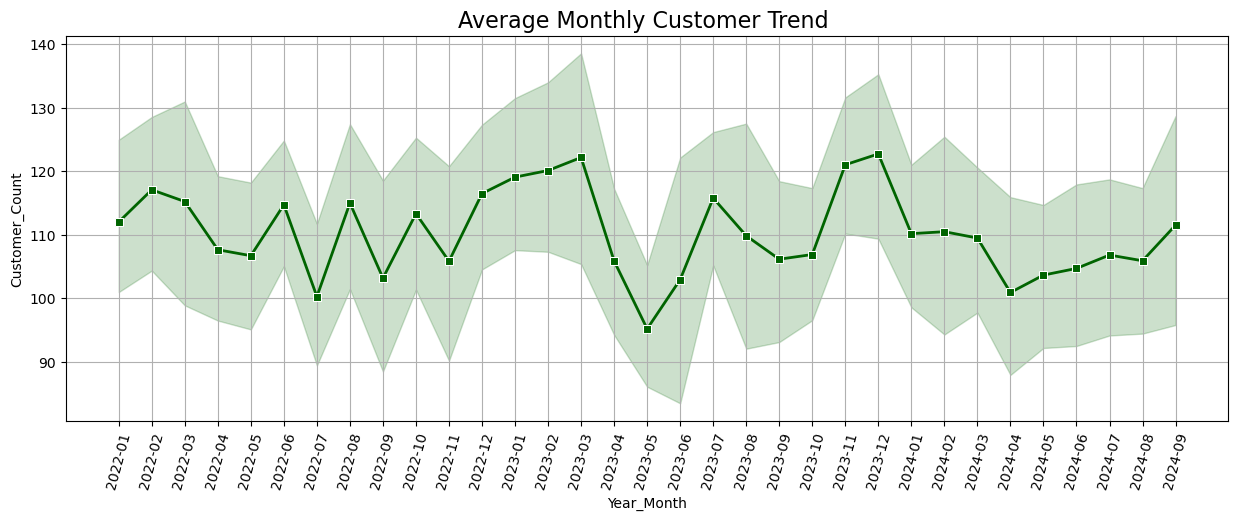

In [15]:
plt.figure(figsize = (15,5))
sns.lineplot(x = "Year_Month", y = "Customer_Count", data = df, marker = "s", linewidth = 2, color = "darkgreen")
plt.title("Average Monthly Customer Trend ", fontsize = 16)
plt.xticks(rotation = 75)
plt.grid(True)
plt.show()

In [16]:
!pip install anaconda-toolbox

### Average Advertising and Sales Trend Over Time

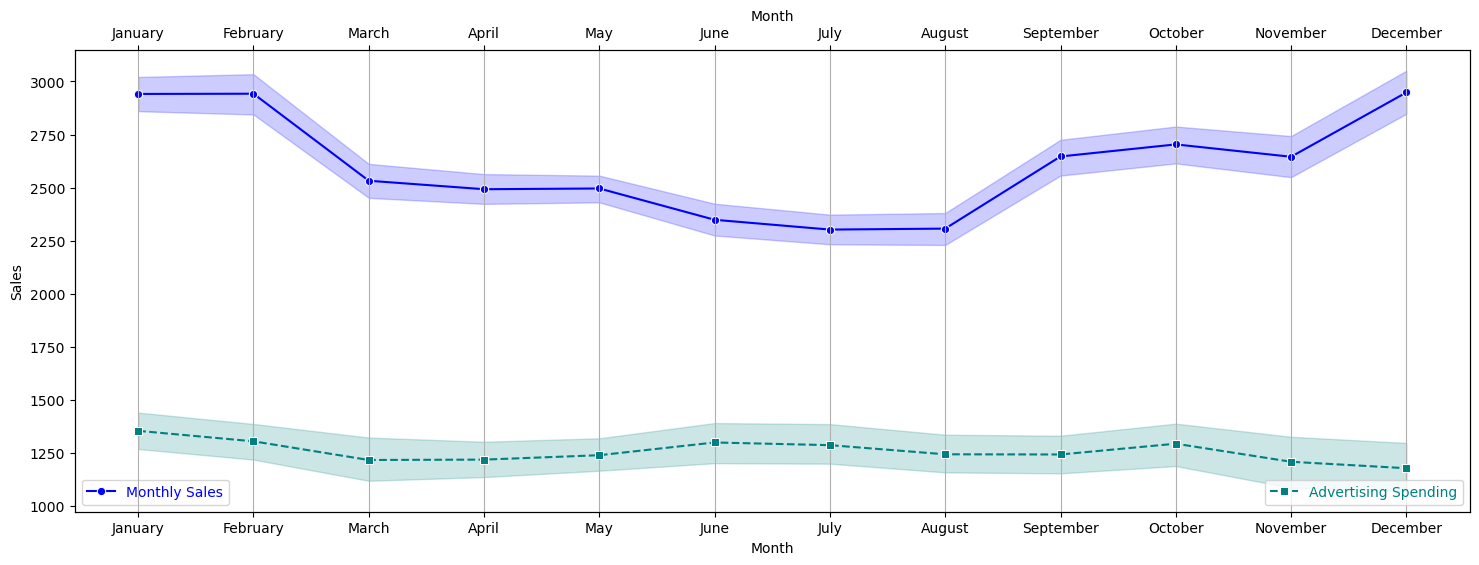

In [17]:
fig, ax = plt.subplots(figsize = (18,6))
sns.lineplot(x = "Month", y = "Sales", data = df, color = "blue", marker = "o")
plt.legend(labels = ["Monthly Sales"], loc = "lower left", labelcolor = "blue")
ax2 = ax.twiny()

sns.lineplot(x = "Month", y = "Advertising", data = df, color = "teal", marker = "s", linestyle = "--")
plt.legend(labels = ["Advertising Spending"], loc = "lower right", labelcolor = "teal")
plt.grid(True)
plt.show()

***Insight***: Sales activity spikes during holiday seasons, opposing  advertisement Trend

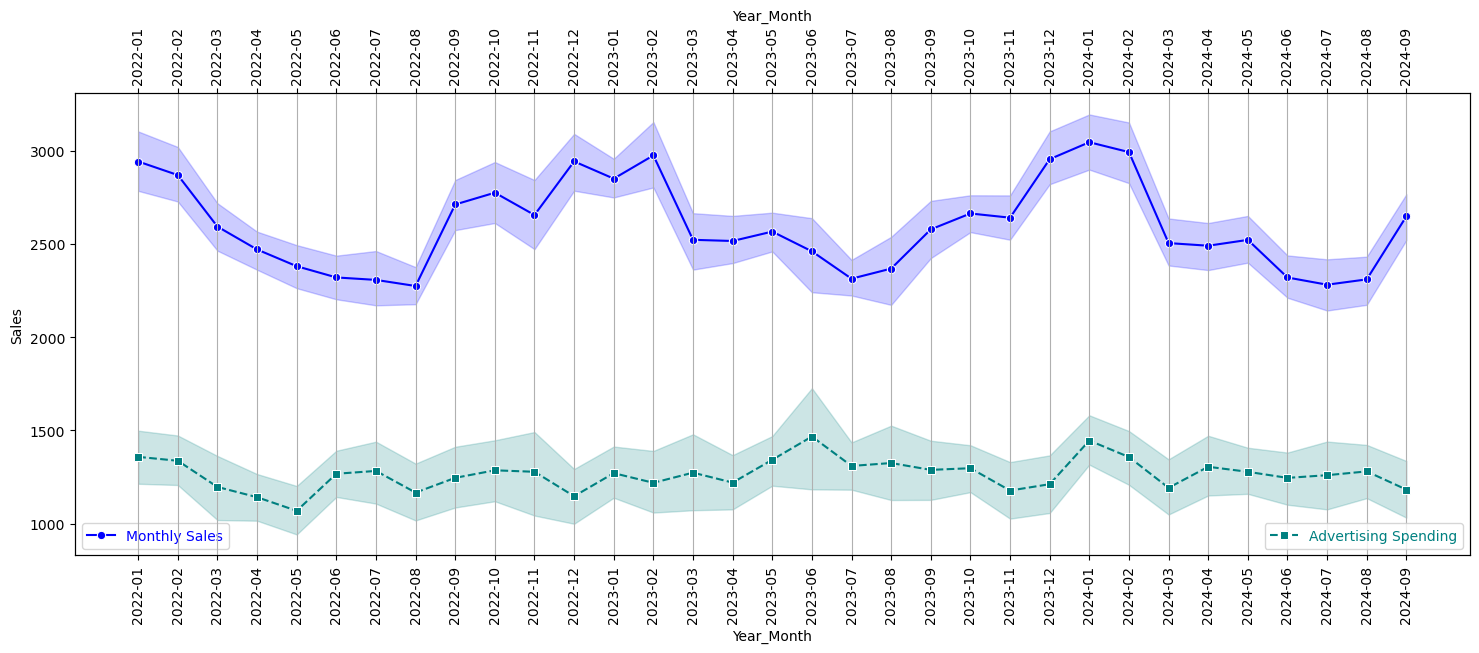

In [18]:
fig, ax = plt.subplots(figsize = (18,6))
sns.lineplot(x = "Year_Month", y = "Sales", data = df, color = "blue", marker = "o", ax= ax)
plt.legend(labels = ["Monthly Sales"], loc = "lower left", labelcolor = "blue")
plt.xticks(rotation = 90)
ax2 = ax.twiny()

sns.lineplot(x = "Year_Month", y = "Advertising", data = df, color = "teal", marker = "s", linestyle = "--")
plt.legend(labels = ["Advertising Spending"], loc = "lower right", labelcolor = "teal")
plt.xticks(rotation = 90)
plt.grid(True)
plt.show()

### Discount Analysis Over Time

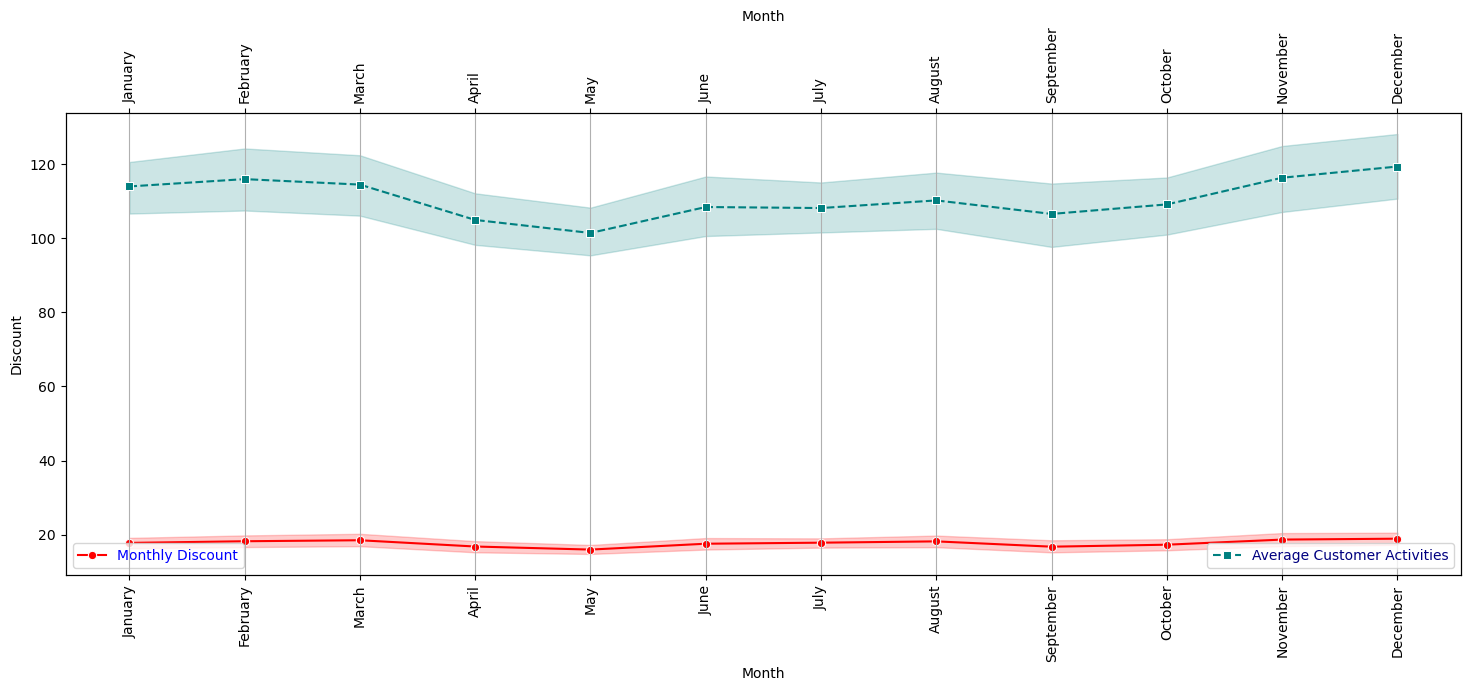

In [19]:
fig, ax = plt.subplots(figsize = (18,6))
sns.lineplot(x = "Month", y = "Discount", data = df, color = "red", marker = "o", ax= ax)
plt.legend(labels = ["Monthly Discount"], loc = "lower left", labelcolor = "blue")
plt.xticks(rotation = 90)
ax2 = ax.twiny()

sns.lineplot(x = "Month", y = "Customer_Count", data = df, color = "teal", marker = "s", linestyle = "--")
plt.legend(labels = ["Average Customer Activities"], loc = "lower right", labelcolor = "navy")
plt.xticks(rotation = 90)
plt.grid(True)
plt.show()

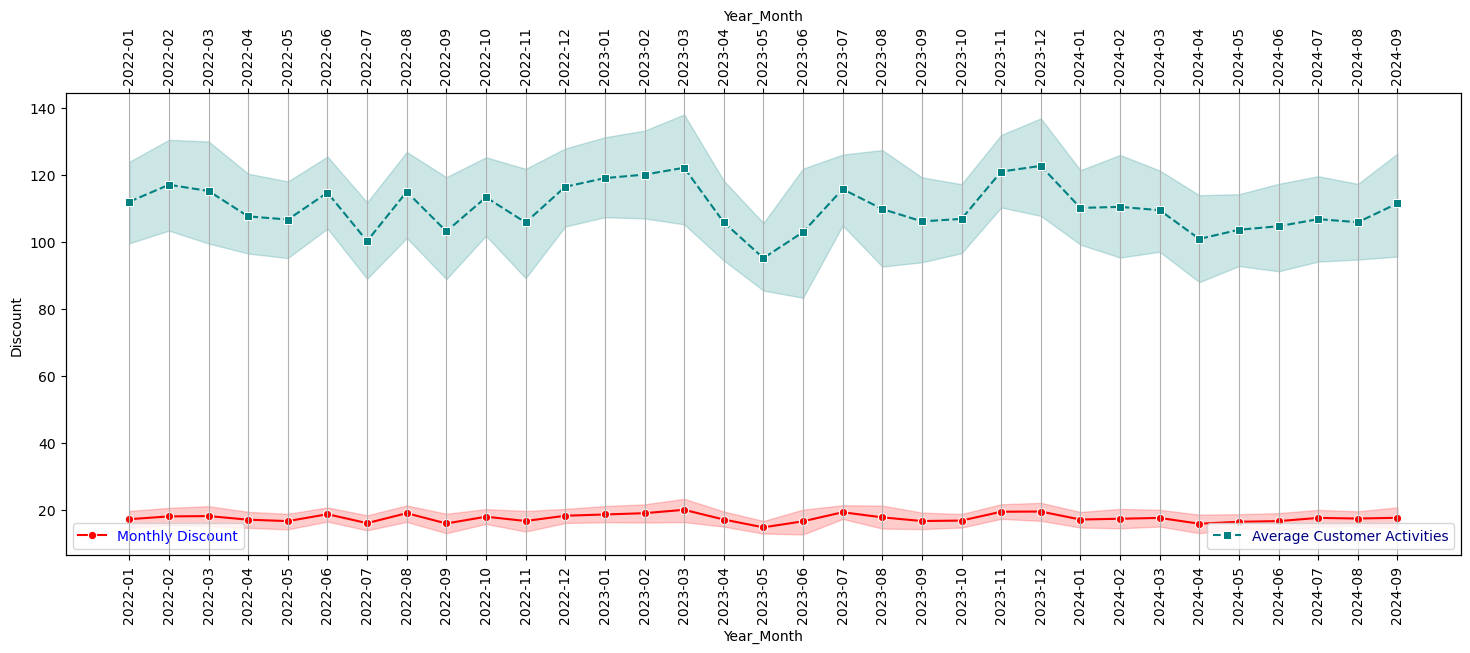

In [20]:
fig, ax = plt.subplots(figsize = (18,6))
sns.lineplot(x = "Year_Month", y = "Discount", data = df, color = "red", marker = "o", ax= ax)
plt.legend(labels = ["Monthly Discount"], loc = "lower left", labelcolor = "blue")
plt.xticks(rotation = 90)
ax2 = ax.twiny()

sns.lineplot(x = "Year_Month", y = "Customer_Count", data = df, color = "teal", marker = "s", linestyle = "--")
plt.legend(labels = ["Average Customer Activities"], loc = "lower right", labelcolor = "navy")
plt.xticks(rotation = 90)
plt.grid(True)
plt.show()

### Numerical and Categorical Analysis

#### Average Sales by Region

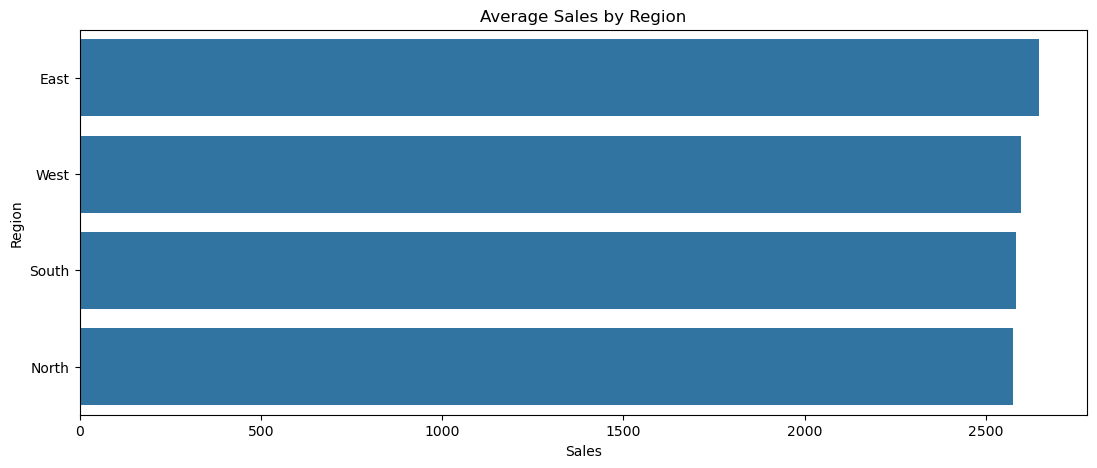

In [24]:
fig, ax = plt.subplots(figsize = (13,5))
sns.barplot(x = "Sales", y = "Region", data = df, orient = "h", errorbar = None)
plt.title("Average Sales by Region")
plt.show()

#### Average Profit by Region

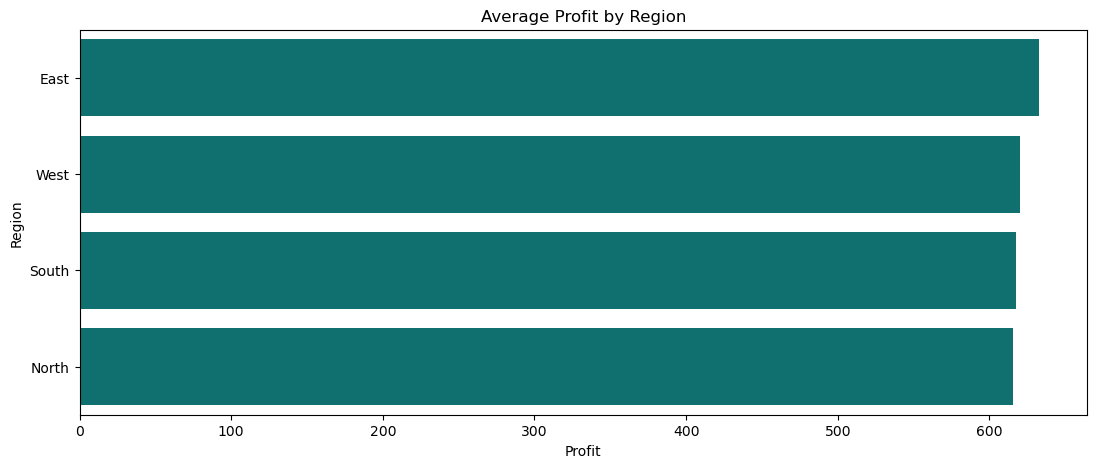

In [27]:
fig, ax = plt.subplots(figsize = (13,5))
sns.barplot(x = "Profit", y = "Region", data = df, orient = "h", errorbar = None, color = "teal")
plt.title("Average Profit by Region")
plt.show()

#### Relationship between Sales and Profit

In [29]:
df.head(2)

,Date,Category,Region,Weather,Advertising,Discount,Month,Year,Season,Sales,Customer_Count,Profit,Year_Month
0,2022-01-01,Home Goods,East,Cloudy,1275.18,15.74,January,2022,Winter,2679.56,95,652.90,2022-01
1,2022-01-02,Electronics,West,Cloudy,1893.89,24.74,January,2022,Winter,3859.05,147,924.16,2022-01


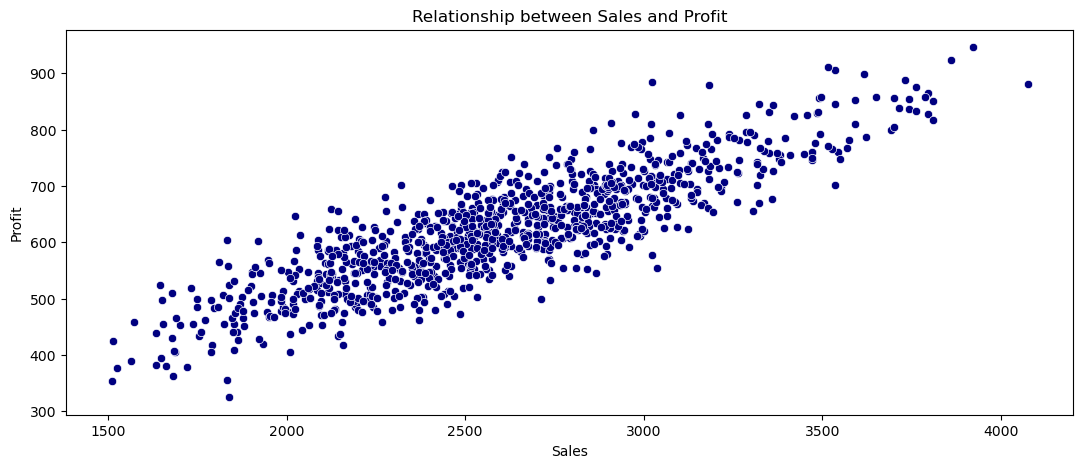

In [44]:
fig, ax = plt.subplots(figsize = (13,5))
sns.scatterplot(x = "Sales", y = "Profit", data = df,color = "navy")
plt.title("Relationship between Sales and Profit")
plt.show()

#### Relationship between Sales and Profit by Season

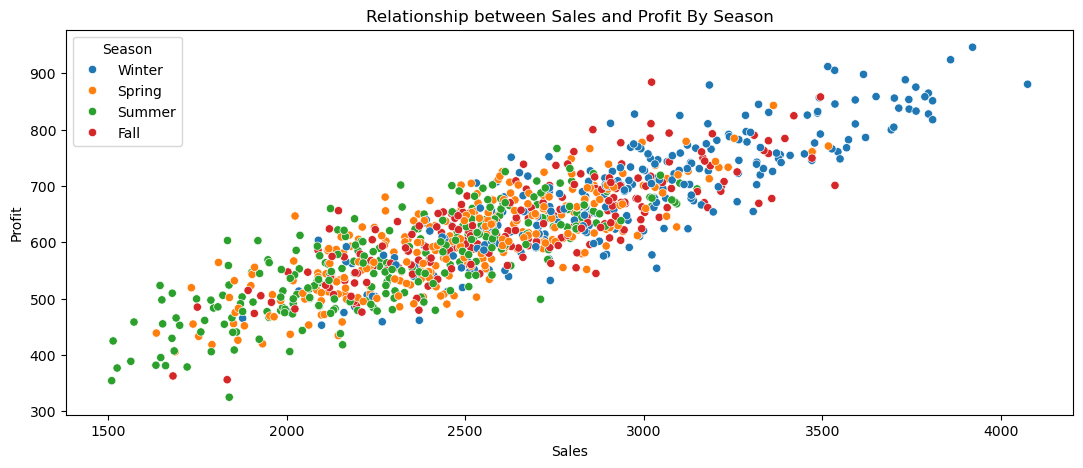

In [43]:
fig, ax = plt.subplots(figsize = (13,5))
sns.scatterplot(x = "Sales", y = "Profit", data = df,hue = "Season")
plt.title("Relationship between Sales and Profit By Season")
plt.show()

#### Relationship between Sales and Profit by Season

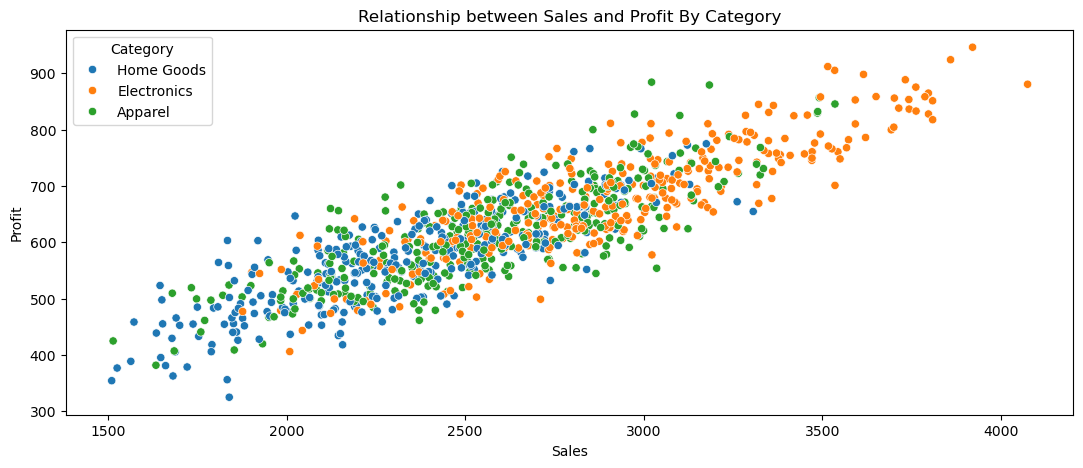

In [35]:
fig, ax = plt.subplots(figsize = (13,5))
sns.scatterplot(x = "Sales", y = "Profit", data = df,hue = "Category")
plt.title("Relationship between Sales and Profit By Category")
plt.show()

#### Relationship between Sales and Profit by Region

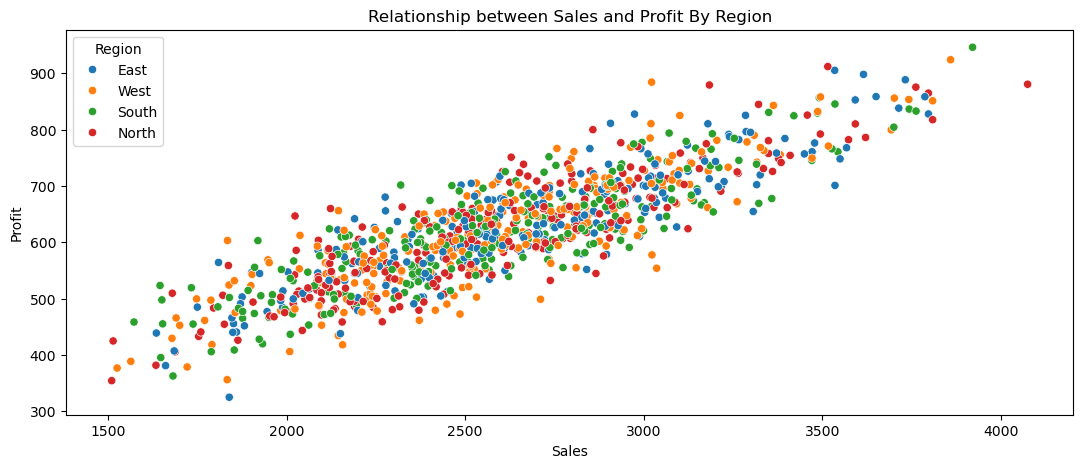

In [36]:
fig, ax = plt.subplots(figsize = (13,5))
sns.scatterplot(x = "Sales", y = "Profit", data = df,hue = "Region")
plt.title("Relationship between Sales and Profit By Region")
plt.show()

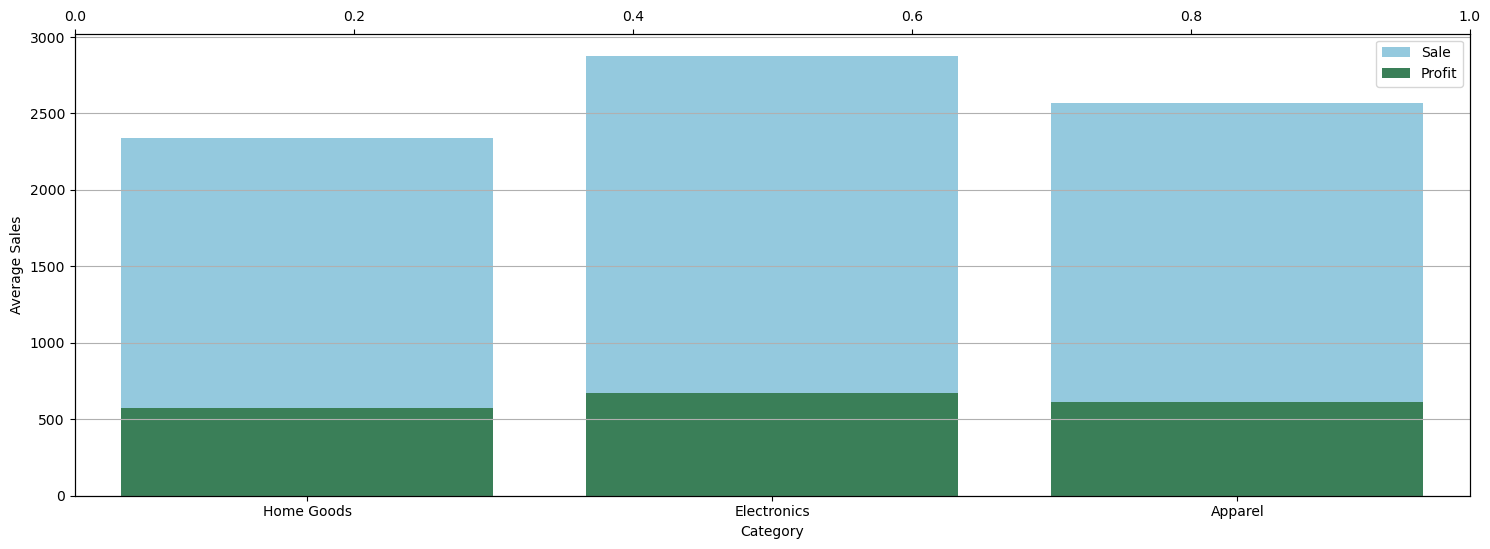

In [47]:
fig, ax = plt.subplots(figsize = (18,6))

sns.barplot(x = "Category", y = "Sales", data = df, color = "skyblue", errorbar = None, ax = ax, label = "Sale")
plt.ylabel("Average Sales")
plt.grid(True)
ax2 = ax.twiny()

sns.barplot(x = "Category", y = "Profit", data = df, color = "seagreen", errorbar = None, ax= ax,label = "Profit")
plt.ylabel("Average Profit")
plt.show()

#### Impact of Advertising on Sales

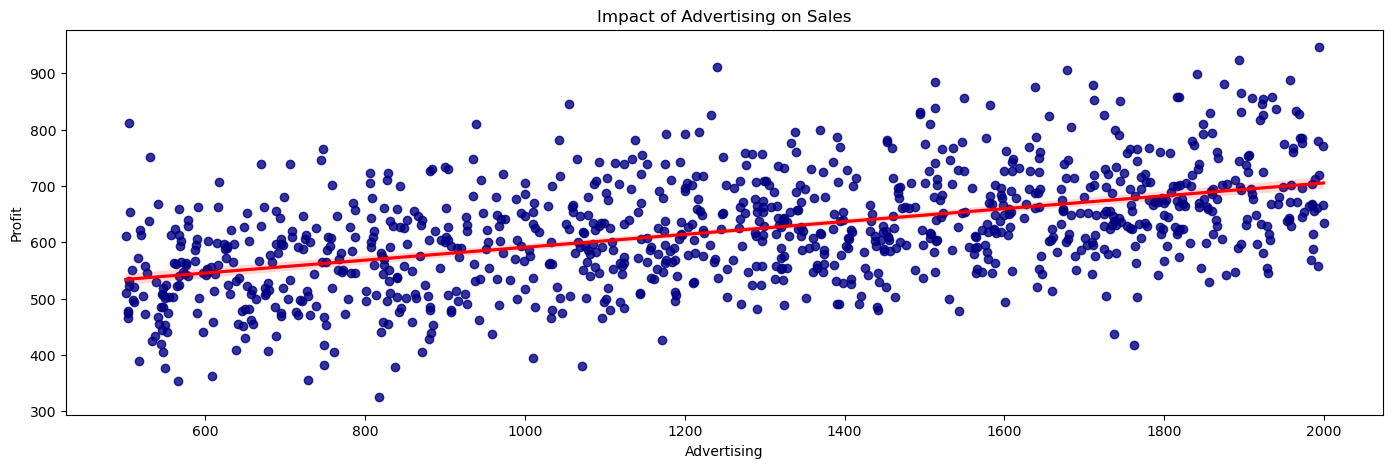

In [49]:
fig, ax = plt.subplots(figsize = (17,5))
sns.regplot(x = "Advertising", y = "Profit", data = df,color = "navy", line_kws = {"color":"red"} )
plt.title("Impact of Advertising on Sales")
plt.show()

#### Discount Impact on the Customer Patronage

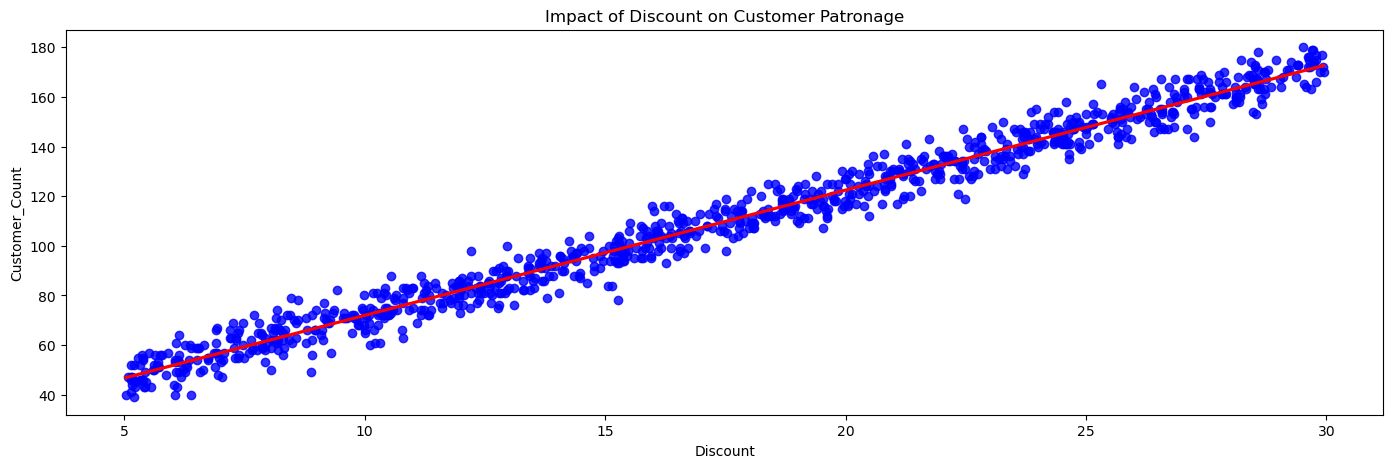

In [51]:
fig, ax = plt.subplots(figsize = (17,5))
sns.regplot(x = "Discount", y = "Customer_Count", data = df,color = "blue", line_kws = {"color":"red"} )
plt.title("Impact of Discount on Customer Patronage")
plt.show()

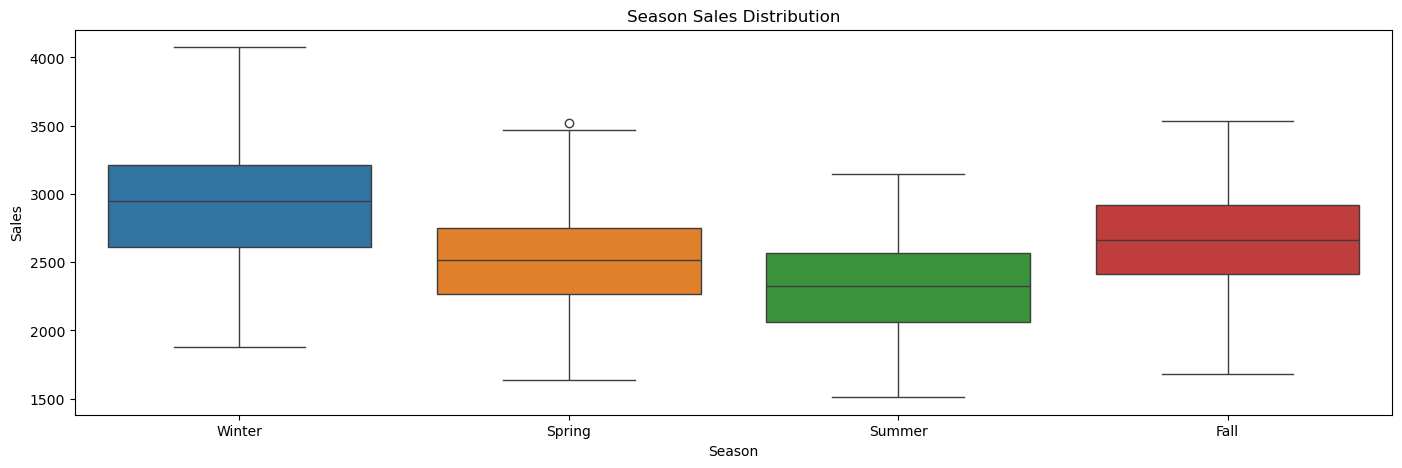

In [52]:
fig, ax = plt.subplots(figsize = (17,5))
sns.boxplot(x = "Season", y = "Sales", data = df, hue = "Season" )
plt.title("Season Sales Distribution")
plt.show()

### Correlation Analysis

In [54]:
numeric_data = df.select_dtypes(include ="number")
numeric_data.head(3)

,Advertising,Discount,Year,Sales,Customer_Count,Profit
0,1275.18,15.74,2022,2679.56,95,652.90
1,1893.89,24.74,2022,3859.05,147,924.16
2,727.38,8.46,2022,2450.71,79,512.75


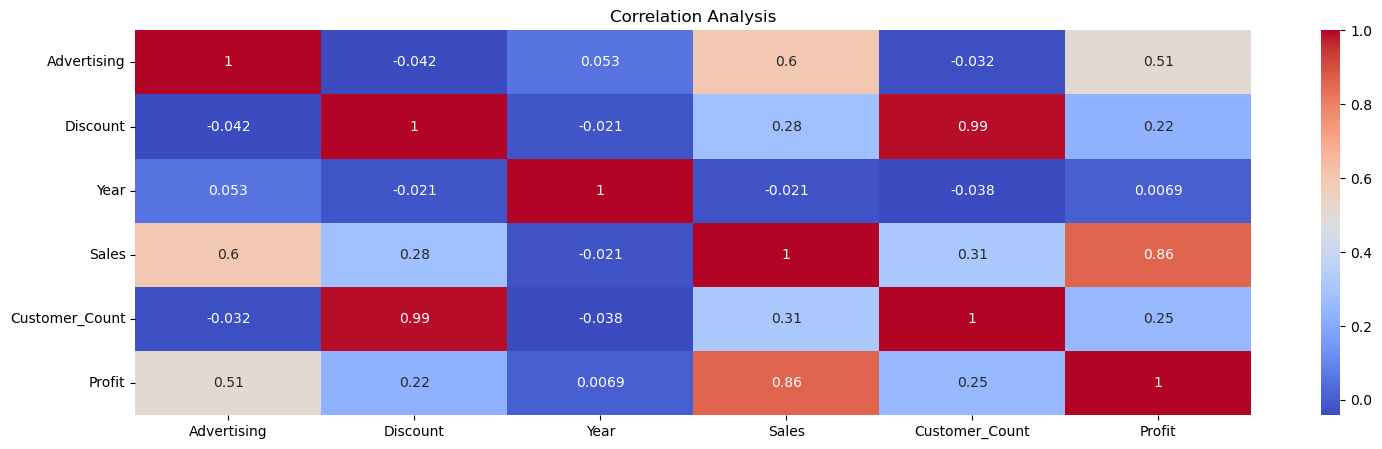

In [56]:
correlation_map = numeric_data.corr()
plt.figure(figsize = (18,5))
sns.heatmap(correlation_map, annot = True, cmap = "coolwarm")
plt.title("Correlation Analysis")
plt.show()